#OrganoMind

##Introduction

The following Jupyter notebook aims to present **OrganoMind**, a pip-installable package designed as an organic Chemistry assistant. The idea behind this package is to provide chemists with a tool to better predict organic reaction outcomes by developing an understanding of molecular reactivity, based on nucleophilic and electrophilic character as well as acid-base properties and functional group identification. OrganoMind also allows chemists to improve their molecular visualization by displaying a 3D representation of molecule and 2D identification of chiral center on the molecule. OrganoMind is mainly built using rdkit, pubchempy and streamlit packages combined with other specific packages, whose installation is detailled in the readme.

This package was created as a collaborative project for the EPFL course *Practical Programming in Chemistry*.

Before delving into the code and the various features offered by OrganoMind, let’s explore the motivations behind this project as well as the chemistry principles used to build the package.

##Motivation

In organic chemistry, when faced with a reaction that needs to be completed, the most important thing is to understand which factors can influence it. From this challenge emerged OrganoMind. 

We wanted to developp a tool which would allows chemists from all around the world to deal with the difficulties of finding the reactive sites of a molecule and therefore gain time when working on organic chemistry reaction. We needed first to define all the thing a molecule posseses that can influence a reaction. From this refelction, we have choosen to focus on the following element: The chirality of the molecule, the detection of the functional groups, as well of potential acidic/basic group and nucleophilic/electrophilic group. Functions, which are implemented in a streamlit UI or can be used seperatly, were developped for each of these elements. **Need to continue**

#Usage of OrganoMind 

Once the package installed, users can take advantage of the full rnage of functions offer by OrganoMind. A function is designed for each molecular characteristic and the section below will outlined the usage of these functions by applying examples.

##Stereochemistry
###`chiral_center()`
This function determines the number of chiral centers in a molecule. It parses the input SMILES string and converts it into an RDKit molecule object using `Chem.MolFromSmiles()`. The chiral centers are then identified using `Chem.FindMolChiralCenters()` with includeUnassigned=True, which returns a list of tuples containing the index and configuration (R/S) of each chiral center. The number of chiral centers is obtained by counting the elements in this list.

In [2]:
from organomind.stereo import chiral_center

chrial_result = chiral_center("CCC(C)(CCC(C)(CO)N)O")

print(chrial_result)

2


###`find_isomers()`
This function determines the number of stereoisomers of the input molecule. It parses the SMILES string and converts it into an RDKit molecule object using `Chem.MolFromSmiles()`. The enumeration options are then set with `StereoEnumerationOptions()`, with unique=True to avoid duplicates, onlyUnassigned=False to consider all stereocenters, and tryEmbedding=True to ensure each isomer is physically realistic in 3D. The number of stereoisomers is then determined by counting the elements in the tuple returned by `EnumerateStereoisomers()`. *Note*: if only one configuration of the molecule exists, the function will return 1.

In [2]:
from organomind.stereo import find_isomers

isomer_result = find_isomers("CCC(C)(CCC(C)(CO)N)O")

print(isomer_result)

4


###`color_chiral()`
This function takes a SMILES string as input and represents the molecule as a 2D structure with its chiral atoms highlighted in green. First, the SMILES string is converted into an RDKit molecule object using Chem.MolFromSmiles(). If the SMILES is invalid, a ValueError is raised. The chiral centers are then identified using `Chem.FindMolChiralCenters()` with includeUnassigned=True, which returns a list of tuples containing the index and the configuration (R/S) of each chiral atom. The atom indices are extracted from this list and passed to `Draw.MolToImage()`, which generates a 2D depiction of the molecule with the chiral atoms highlighted in green. If no chiral centers are found, the function returns None.

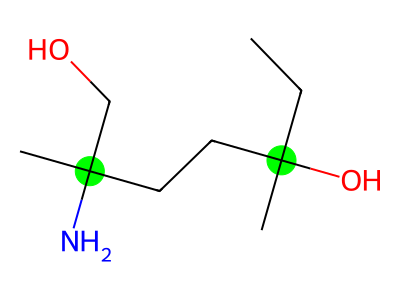

In [3]:
from organomind.stereo import color_chiral
from IPython.display import display

img = color_chiral("CCC(C)(CCC(C)(CO)N)O")
display(img)

##Aromatic groups
###`detect_aromatic()`
This function detects whether aromatic groups are present in a molecule and, if so, returns a DataFrame containing the name of each aromatic group, the number of times it appears in the molecule, and its position. A dictionary called aromatic_patterns (in Data/aromatic_data.py) serving as a database was created beforehand, containing aromatic group names as keys and their corresponding precompiled RDKit pattern objects as values. The input SMILES string is first converted into an RDKit molecule object using `Chem.MolFromSmiles()`. The function then iterates through the dictionary and uses `GetSubstructMatches()` to check if each pattern is present in the molecule. The matches are collected into a list and returned as a pandas DataFrame. If no aromatic group is detected, the function returns an empty DataFrame with a 'None' entry.

In [ ]:
from organomind.aromatic import detect_aromatic

result_aromatic = detect_aromatic("C1=CC=C(C=C1)C(C2=CC=C(C=C2)CC3=COC=C3)C4=CNC=C4")

display(result_aromatic)

,Aromatic Group,Count,Position
0,benzene,2,"[[0, 1, 2, 3, 4, 5], [7, 8, 9, 10, 11, 12]]"
1,furan,1,"[[14, 18, 17, 16, 15]]"
2,pyrrole,1,"[[19, 23, 22, 21, 20]]"


##Functional Groups

###`detect_functional_groups()`

This function identifies the functional groups present in a molecule from a SMILES string. It first converts the SMILES into an RDKit molecule object using `Chem.MolFromSmiles()`. The function then loops through the functional group database, where each functional group is represented by a SMARTS pattern. Each SMARTS pattern is converted into an RDKit pattern using `Chem.MolFromSmarts()`. The function then uses `GetSubstructMatches()` to check whether that pattern appears in the molecule. For each functional group found, the function stores the group name, the number of times it appears, and the atom positions where it was detected. The result can be returned either as a dictionary or as a pandas DataFrame, depending on the value of `return_df`.

In [5]:
from organomind.functional_groups import detect_functional_groups

fg_result = detect_functional_groups("CC(=O)Oc1ccccc1C(=O)O")

display(fg_result)

,Functional Group,Count,Position
0,carboxylic acid,1,"((10, 11, 12),)"
1,ester,1,"((1, 2, 3, 4),)"
2,benzene ring,1,"((4, 5, 6, 7, 8, 9),)"


###`highlight_functional_groups()`

This function gives a 2D visual representation of the molecule with its detected functional groups highlighted. It first converts the SMILES into an RDKit molecule object using `Chem.MolFromSmiles()`. Then, it uses `detect_functional_groups()` to identify the functional groups present in the molecule. For each detected group, the function retrieves the corresponding SMARTS pattern from the functional group database and converts it using `Chem.MolFromSmarts()`. The atom positions returned by the detection function are used to create a list of atoms to highlight. In addition, the bonds between these atoms are identified using `GetBondBetweenAtoms()`  to highlight the bonds of the functional group as well. Each functional group is assigned a different color. These colors are stored in dictionaries for atoms and bonds, then passed to RDKit’s drawing function `rdMolDraw2D.PrepareAndDrawMolecule()`. The drawing is then converted into an SVG image using `GetDrawingText()`, and a legend is added to indicate which color corresponds to each functional group. The SVG is displayed in Streamlit using `components.html()` and returned by the function.

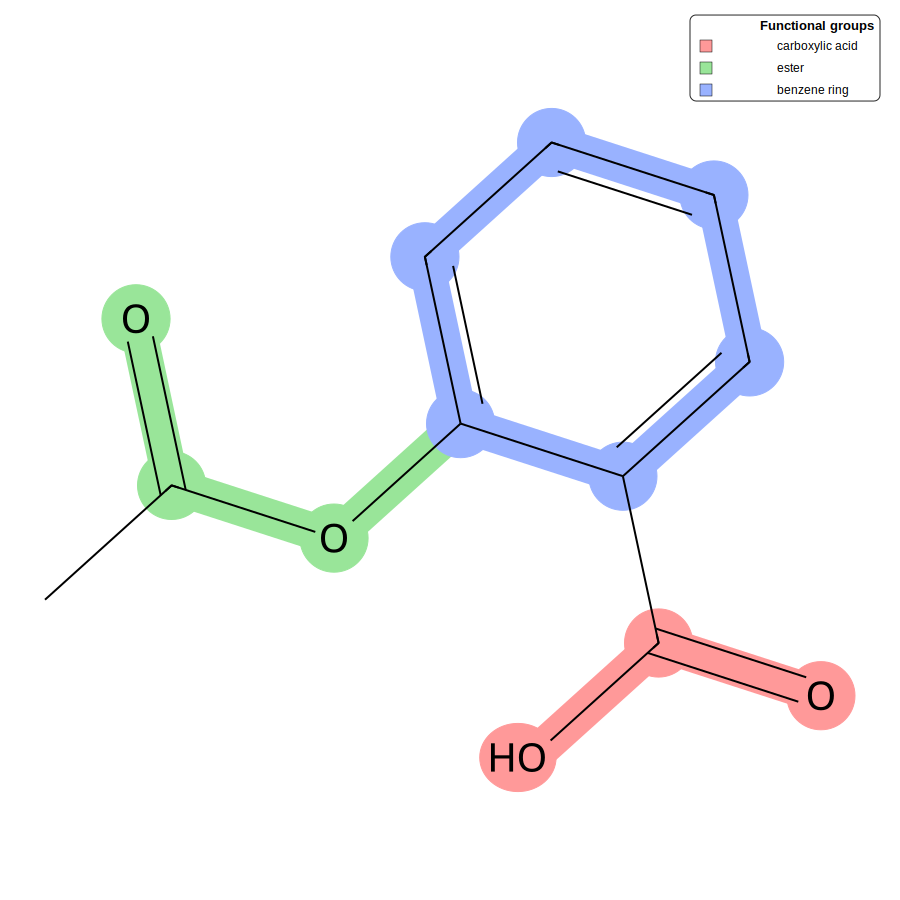

In [1]:
from organomind.highlight_functional_groups import draw_molecule_with_functional_groups
from IPython.display import SVG, display

smiles = "CC(=O)Oc1ccccc1C(=O)O"
svg = draw_molecule_with_functional_groups(smiles, filename="aspirin_highlighted.svg", show_streamlit=False)

display(SVG("aspirin_highlighted.svg"))

##Acidity/Basicity
###`acid_base_estimate()`
This function gives an estimate of pkA for acidic and basic behavior of the given molcule. It uses `detect_functional_groups()`, and compares the results with the `acid_base_info` database. The database consists of the type of funcitonal group, its strength, approximate pka range and its priority. A list is created and the acidic/basic functional grousp presents are added, taking note of the data in the base with addition to the number of times it is present. By ordering them in respect to the priority, a dataframe is returned.

In [6]:
from organomind.acidity import acid_base_estimate
smiles = "CCC(CO)N"
acidic_groups, basic_groups = acid_base_estimate(smiles)

print("Acidic group:")
display(acidic_groups)

print("Basic group:")
display(basic_groups)

Acidic group:


,group,count,positions,type,strength,pka_range,priority
0,alcohol,1,"((4, 3),)",acidic,extremely weak,16-18,6


Basic group:


,group,count,positions,type,strength,pka_range,priority
0,primary amine,1,"((5, 2),)",basic,weak,conjugate acid pKa 9-11,1


##Point groups
###`find_group()`
This function gives the point group of the given molecule. It first converts the SMILES into an RDKit molecule object using `MolFromSmiles()`. The hydrogens present in the moelcule are added using `Chem.AddHs()`. The function then generates a 3D structure using `AllChem.EmbedMolecule()` with the ETKDG method and optimizes the geometry using `AllChem.MMFFOptimizeMolecule()`. The atom symbols and their 3D coordinates are extracted from the RDKit conformer. These atoms and coordinates are then passed to pymatgen as a Molecule object. Finally, PointGroupAnalyzer is used to estimate the molecular point group.

In [10]:
from organomind.point_groups import find_group

print("Methane:", find_group("C"))
print("Benzene:", find_group("c1ccccc1"))

Methane: Td
Benzene: D6h


##3D representation
###`draw_molecule_3D()`
This function generates an interactive 3D representation of a molecule from a SMILES string. The SMILES is first converted into an RDKit molecule object using `Chem.MolFromSmiles()`. Hydrogen atoms are then explicitly added using `Chem.AddHs()`, which is necessary for accurate 3D geometry. `AllChem.EmbedMolecule()` allows to generate the 3D coordinates of the molecule are generated using with the ETKDGv3 algorithm, and the geometry is then optimized using the MMFF (Merck Molecular Force Field) via `AllChem.MMFFOptimizeMolecule()`. The resulting 3D structure is exported as an SDF block using `Chem.MolToMolBlock()` and loaded into a py3Dmol viewer. The visualization style, color, dimensions, and background color are all customizable through the function parameters. Finally, the interactive 3D viewer is rendered using `components.html()`, which embeds it as an HTML component in a Streamlit application. *Note*: As previously said, the interactive 3D viewer is render through `components.html()`. This was done as it is the most optimal way to display a 3D representation of the molecule in streamlit. However, this is not compatible with Jupyter notebook. Therefore, the right command to use correctly `draw_molecule_3D()` is the one after (#), but an image of the output on stramlit is represented in the report using `display()`.

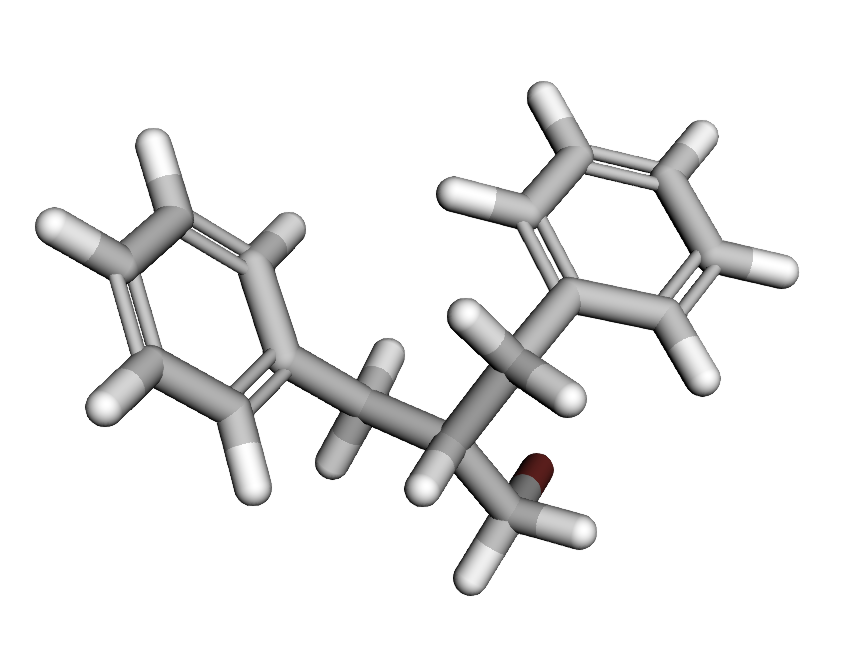

In [8]:
from organomind.draw3D import draw_molecule_3d
from IPython.display import Image, display

#draw_molecule_3d("C1=CC=C(C=C1)CC(CC2=CC=CC=C2)CBr")

display(Image(filename='3D_draw.png', width=400))

##CAS registry number
###`filter_cas()`
This function extracts the CAS registry number of a molecule from its list of PubChem synonyms. CAS numbers are not explicitly provided by the PubChem database, however each molecule entry contains a long list of synonyms which always includes the CAS registry number, but never at a fixed position. The function takes this list of synonyms as input. If no list of synonyms exists, the function returns `None`. Otherwise, it iterates through the list and uses `re.match()` with a CAS number pattern to identify the correct entry. The first match found is returned by the function.

In [2]:
from organomind.cas import filter_cas
import pubchempy as pcp

results = pcp.get_synonyms('CC(C(=O)O)O', 'smiles')
synonyms = results[0]['Synonym']

print(filter_cas(synonyms))


50-21-5


##Nucleophilicity/Electrophilicity ###`electro_nucleo_sites_hsab()`
Gasteiger charges are partial atomic charges computed from the electronegativity and connectivity of each atom in a molecule. They provide a fast approximation of the electron density distribution without requiring quantum chemical calculations. Atoms with a large negative Gasteiger charge tend to be electron-rich (nucleophilic), while atoms with a large positive charge tend to be electron-poor (electrophilic). However, Gasteiger charges have known limitations — they do not capture mesomeric effects, polarizability of large atoms such as sulfur, or solvent effects. For this reason, HSAB (Hard and Soft Acids and Bases) theory corrections are applied on top of the raw charges to better reflect chemical reactivity.

 This function identifies the most electrophilic and nucleophilic sites of a molecule by combining Gasteiger partial charges with HSAB (Hard and Soft Acids and Bases) theory corrections. The function assumes a neutral environment (pH = 7). The function takes a SMILES string or RDKit Mol object as input. It first computes Gasteiger charges for each atom, then detects functional groups using `detect_functional_groups()`. Each atom is assigned a nucleophilicity and electrophilicity score based on its raw Gasteiger charge corrected by HSAB bonuses shown in the nucleo_data database. Atoms with formal charges also receive an additional correction. The function returns two pandas Series: one for the atom with the highest electrophilicity score (most electrophilic site) and one for the atom with the lowest nucleophilicity score (most nucleophilic site).

In [16]:
from organomind.nucelo_electro import electro_nucleo_sites_hsab
import pubchempy as pcp
import pandas as pd

compound = pcp.get_compounds("aspirine", "name")[0]
smiles = compound.smiles

most_electrophilic_drop, most_nucleophilic_drop = electro_nucleo_sites_hsab(smiles)

print("Most electrophilic site:")
display(pd.DataFrame([most_electrophilic_drop]))
print("Most nucleophilic site:")
display(pd.DataFrame([most_nucleophilic_drop]))

Most electrophilic site:


,atom idx,symbol,functional group,type
1,1,C,ester,electrophile


Most nucleophilic site:


,atom idx,symbol,functional group,type
12,12,O,carboxylic acid,nucleophile
